# MSc Thesis
# Mode choice responses during dynamic street space allocation: A stated preference experiment on mode choice in Amsterdam
#### R.F. Ghofir - Delft University of Technology, 2026

## `Part A: Data analysis`

### `1. Project setup`

In [1]:
# General python packages

import re
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from pathlib import Path

# Pandas setting to show all columns when displaying a pandas dataframe
pd.set_option('display.max_columns', None)
plt.rcParams["figure.figsize"] = (8,5)

### `2. Load dataset`

**Description of variables**<br>

| Variable | Description | Values / Levels |
|----------|-------------|-----------------|
| `screening_car` | Primary commuting mode is a private car | Yes, No |
| `screening_loc_1` | Home postcode (4-digit) | Numeric |
| `screening_loc_3` | Work/school postcode (4-digit) | Numeric |
| `home_municipality` | Home municipality (derived from postcode) | Amsterdam, Amstelveen, Diemen, Gooise Meren, Haarlemmermeer, Landsmeer, Oostzaan, Waterland, Zaanstad |
| `work_municipality` | Work municipality (derived from postcode) | Amsterdam, Amstelveen, Diemen, Gooise Meren, Haarlemmermeer, Landsmeer, Oostzaan, Waterland, Zaanstad |
| `tb_tt` | Current commuting travel time by car | Minutes |
| `tb_tr` | Current travel time reliability (early arrival) | ±0–2, ±2–5, ±5–10, ±10–15, ±15–20, ±20–30, >±30 min |
| `tb_tr_late` | Current travel time reliability (late arrival) | ±0–2, ±2–5, ±5–10, ±10–15, ±15–20, ±20–30, >±30 min |
| `tb_td` | Current commuting distance | Kilometres |
| `tb_type` | Vehicle fuel type | Petrol, Diesel, Electric, Hybrid |
| `tb_park` | Parking cost per trip | No cost, <€2, €2–5, €5–8, €8–10, €10–15, €15–20, €20–30, >€30 |
| `TC_e` | Current travel cost per trip | Euro (€) |
| `tb_freq` | Weekly commuting frequency | 1–5 days/week, >5 days/week |
| `tb_sched` | Work schedule flexibility | Fixed, Flexible, Other, Rather not say |
| `example_choice` | Practice choice task | Private car, Bus, Bicycle |
| `SP_answer_block_*` | Stated preference choice responses | Private car, Bus, Bicycle |
| `Attitude_1_liveability` | Reducing car use improves urban liveability | 5-point Likert scale |
| `Attitude_2_equity` | Lane reallocation improves transport equity | 5-point Likert scale |
| `Attitude_3_habits` | Willingness to change commuting habits | 5-point Likert scale |
| `Attitude_4_feasible` | Dynamic street allocation is feasible | 5-point Likert scale |
| `Attitude_5_reliability` | Reliability is more important than travel time | 5-point Likert scale |
| `Attitude_6_variation` | Travel time variation does not bother me | 5-point Likert scale |
| `Attitude_7_punctual` | Arriving on time is important | 5-point Likert scale |
| `Attitude_8_uncertainty` | Discomfort with travel uncertainty | 5-point Likert scale |
| `Attitude_9_expectation` | Travel uncertainty can improve outcomes | 5-point Likert scale |
| `Attitude_10_adapt` | Comfortable adapting to uncertainty | 5-point Likert scale |
| `Attitude_11_cycle` | Comfortable cycling long distances | 5-point Likert scale |
| `Attitude_12_convenience` | DSSA improves travel convenience | 5-point Likert scale |
| `Attitude_13_confusing` | Dynamic streets are confusing | 5-point Likert scale |
| `Attitude_14_drive` | I enjoy driving | 5-point Likert scale |
| `Age_1_TEXT` | Year of birth | Integer / Rather not say |
| `age` | Age (derived) | Years |
| `age_group` | Age group (derived) | <20, 20–39, 40–64, 65–79, ≥80, Not stated |
| `gender` | Gender | Male, Female, Other/non-binary, Rather not say |
| `education` | Highest education level | Primary/VMBO/MBO-1, HAVO/VWO/MBO2–4, HBO, University, Other, Rather not say |
| `employment` | Employment status | Full-time, Part-time, Self-employed, Student, Unemployed, Other, Rather not say |
| `HH_comp` | Household composition | Single, Couple (no children), Couple (children), Single parent, Other, Rather not say |
| `HH_income` | Annual household income | Survey categories |
| `bike` | Bicycle ownership | Regular bike, E-bike, Other bike, No bicycle, Never commute by bicycle, Rather not say |
| `PT_subs` | Public transport subscription | Discount pass, Unlimited pass, Employer covered, None, Other, Rather not say |
| `FAC1_support` | Latent factor: Policy support | Continuous factor score |
| `FAC2_uncertainty` | Latent factor: Uncertainty sensitivity | Continuous factor score |
| `FAC3_reliability` | Latent factor: Reliability preference | Continuous factor score |

In [8]:
# Load and read input files
postcode_file = Path(f'data/postcode_mapping.csv')
survey_file   = Path(f'data/SP_data_4june (incl. EFA).csv')
design_file   = Path(f'data/surveydesign.xlsx')

df            = pd.read_csv(survey_file, sep=",")
postcode_map  = pd.read_csv(postcode_file)
design        = pd.read_excel(design_file)

# print(survey_file)
# print(df.shape)
#df.head()

### `3. Helper functions`

In [38]:
attitude_cols = [
    'Attitude_1_liveability','Attitude_2_equity','Attitude_3_habits','Attitude_4_feasible',
    'Attitude_5_reliability','Attitude_6_variation','Attitude_7_punctual', 'Attitude_8_uncertainty',
    'Attitude_9_expectation','Attitude_10_adapt','Attitude_11_cycle', 'Attitude_12_convenience',
    'Attitude_13_confusing','Attitude_14_drive'
]

def histogram(series, title, xlabel, ylabel="Frequency", bins=30, xlim=None,):
    fig, ax = plt.subplots(figsize=(8, 5))
    series.dropna().hist(bins=bins, edgecolor="black", ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if xlim is not None:
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.show()

# ============================================================
# CURRENT COMMUTING PLOTS
# ============================================================

commute_plots = {
    "tb_tt"      : {"title": "Current travel time (min)"},
    "tb_td"      : {"title": "Current travel distance (km)"},
    "TC_e"       : {"title": "Current travel cost (€ / trip)"},
    "tb_park"    : {"title": "Parking cost (€ / trip)"},
    "tb_type"    : {
        "title"  : "Vehicle type",
        "mapping": {0.12: "Petrol", 0.13: "Diesel", 0.07: "Electric", 0.09: "Hybrid"},
        "order"  : ["Petrol", "Diesel", "Electric", "Hybrid"],
    },
    "tb_tr": {
        "title"  : "Early arrival reliability",
        "mapping": {1: "±0–2", 2: "±2–5", 3: "±5–10", 4: "±10–15", 5: "±15–20", 6: "±20–30", 7: ">30"},
        "order"  : ["±0–2", "±2–5", "±5–10", "±10–15", "±15–20", "±20–30", ">30"],
    },
    "tb_tr_late" : {
        "title"  : "Late arrival reliability",
        "mapping": {1: "±0–2", 2: "±2–5", 3: "±5–10", 4: "±10–15", 5: "±15–20", 6: "±20–30", 7: ">30"},
        "order"  : ["±0–2", "±2–5", "±5–10", "±10–15", "±15–20", "±20–30", ">30"],
    },
    "tb_freq"    : {
        "title"  : "Commuting frequency",
        "mapping": { 1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: ">5"},
        "order"  : ["1", "2", "3", "4", "5", ">5"],
    },
    "tb_sched"   : {
        "title"  : "Schedule flexibility",
        "mapping": {1: "Fixed", 2: "Flexible", 3: "Other", 4: "Not say"},
        "order"  : ["Fixed", "Flexible", "Other", "Not say"],
    },
}

# ============================================================
# SOCIODEMOGRAPHIC PLOTS
# ============================================================

sociodemo_plots = {
    "age": {"title": "Age"},
    "age_group": {
        "title": "Age group",
        "mapping": {1: "<20", 2: "20–39", 3: "40–64", 4: "65–79", 5: ">80", 6: "Not say"},
        "order": ["<20", "20–39", "40–64", "65–79", ">80", "Not say"],
    },
    "gender": {
        "title": "Gender",
        "mapping": {1: "Male", 2: "Female", 3: "Other / non-binary", 4: "Not say"},
        "order": ["Male", "Female", "Other / non-binary",
            "Not say",
        ],
    },

    "education": {
        "title": "Education",
        "mapping": {1: "Primary / VMBO / MBO-1", 2: "HAVO / VWO / MBO 2-4", 3: "HBO", 4: "University", 5: "Other", 6: "Not say"},
        "order": ["Primary / VMBO / MBO-1", "HAVO / VWO / MBO 2-4", "HBO", "University", "Other", "Not say"],
    },
    "employment": {
        "title": "Employment status",
        "mapping": { 1: "Employee (FT)", 2: "Employee (PT)", 3: "Self-employed (+)", 4: "Self-employed",
            5: "Student", 6: "Unemployed", 7: "Other", 8: "Not say"},
        "order": ["Employee (FT)", "Employee (PT)", "Self-employed (+)", "Self-employed", "Student", "Unemployed", "Other", "Not say"],
    },
    "HH_comp": {
        "title": "Household composition",
        "mapping": {1: "Single", 2: "Couple", 3: "Couple + children", 4: "Single parent", 5: "Other", 6: "Not say"},
        "order": ["Single", "Couple", "Couple + children", "Single parent", "Other", "Not say"],
    },

    "HH_income": {
        "title": "Household income (€1,000)",
        "mapping": {
            1:"0–20",2:"20–30",3:"30–40",4:"40–50",
            5:"50–60",6:"60–70",7:"70–80",8:"80–90",
            9:"90–100",10:"100–110",11:"110–120",
            14:"120–130",15:"130–140",16:"140–150",
            12:">150",13:"Not say"
        },
        "order":[
            "0–20","20–30","30–40","40–50",
            "50–60","60–70","70–80","80–90",
            "90–100","100–110","110–120",
            "120–130","130–140","140–150",
            ">150","Not say"
        ],
    },

    "bike": {
        "title": "Bike ownership",
        "mapping": {1:"Regular bike", 2:"E-bike", 3:"Other bike", 4:"No bike", 5:"Never commute by bike", 6:"Not say"},
        "order":["Regular bike", "E-bike", "Other bike", "No bike", "Never commute by bike", "Not say"],
    },

    "PT_subs": {
        "title":"Public transport subscription",
        "mapping":{1:"Discount pass", 2:"Unlimited pass", 3:"Employer covered", 4:"No subscription", 5:"Other", 6:"Not say"},
        "order":["Discount pass", "Unlimited pass", "Employer covered", "No subscription", "Other", "Not say"],
    },
}

### `4. Data cleaning`

In [29]:
# ============================================================
# LAUNCH DATE FILTER
# ============================================================

date_col = "StartDate"
launch_date = pd.Timestamp("2026-05-10")

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df[df[date_col] > launch_date].copy()
else:
    print(f"Warning: '{date_col}' not found. Date filtering skipped.")



# ============================================================
# REGIONS AND CAR USERS ELIGIBILITY FILTER
# ============================================================

# Convert relevant variables to numeric
numeric_cols = ["Finished", "screening_car", "screening_loc_1", "screening_loc_3", "TT"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
postcode_map["postcode4"] = pd.to_numeric(postcode_map["postcode4"], errors="coerce")


# Zipcode to municipality lookup
# Remove respondents with missing postcode information
df = df[df['screening_loc_1'].notna() & df['screening_loc_3'].notna()].copy()

# Map postcode to municipality
postcode_dict = dict(zip(postcode_map['postcode4'], postcode_map['municipality']))

df['home_municipality'] = df['screening_loc_1'].map(postcode_dict)
df['work_municipality'] = df['screening_loc_3'].map(postcode_dict)

df['eligible_region'] = (df['home_municipality'].notna() & df['work_municipality'].notna())

# Apply eligibility criteria
df_clean = df[
    (df['Finished'] == 1) &
    (df['screening_car'] == 1) &
    (df['eligible_region']) &
    (df['TT'].notna())
].copy()

# Reset index
df_clean.reset_index(drop=True, inplace=True)

print(f"Eligible completed responses: {len(df_clean)}")


# ============================================================
# QUALITY CHECKS
# ============================================================

# Remove speeders
min_duration = 120 #seconds

n_before = len(df_clean)

df_clean = df_clean[df_clean['Durationinseconds'] >= min_duration].copy()

print(f"Removed by speed quality check (<{min_duration}s): {n_before - len(df_clean)}")


# Straightliners
df_clean[attitude_cols] = df_clean[attitude_cols].apply(pd.to_numeric,errors='coerce')

n_before = len(df_clean)

df_clean['attitude_range'] = (df_clean[attitude_cols].max(axis=1)- df_clean[attitude_cols].min(axis=1))

df_clean = df_clean[df_clean['attitude_range'] > 0].copy()
print(f"Removed by straightliner quality check: {n_before - len(df_clean)}")

df_clean.drop(columns=['attitude_range'], inplace=True)
print(f"Final sample: {len(df_clean)}")

# Preview
df_clean.head()

Eligible completed responses: 522
Removed by speed quality check (<120s): 9
Removed by straightliner quality check: 30
Final sample: 483


,StartDate,EndDate,Status,Progress,Durationinseconds,Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,screening_car,screening_loc_1,screening_loc_3,tb_tt,tb_tr,tb_tr_late,tb_td,tb_type,tb_park,tb_park_0_TEXT,tb_park_0.5_TEXT,tb_freq,tb_sched,tb_sched_3_TEXT,example_choice,@1_SP_answer_block_1,@2_SP_answer_block_1,@3_SP_answer_block_1,@4_SP_answer_block_1,@5_SP_answer_block_1,@6_SP_answer_block_1,@7_SP_answer_block_1,@8_SP_answer_block_1,@9_SP_answer_block_1,@1_SP_answer_block_2,@2_SP_answer_block_2,@3_SP_answer_block_2,@4_SP_answer_block_2,@5_SP_answer_block_2,@6_SP_answer_block_2,@7_SP_answer_block_2,@8_SP_answer_block_2,@9_SP_answer_block_2,@1_SP_answer_block_3,@2_SP_answer_block_3,@3_SP_answer_block_3,@4_SP_answer_block_3,@5_SP_answer_block_3,@6_SP_answer_block_3,@7_SP_answer_block_3,@8_SP_answer_block_3,@9_SP_answer_block_3,Attitude_1_liveability,Attitude_2_equity,Attitude_3_habits,Attitude_4_feasible,Attitude_5_reliability,Attitude_6_variation,Attitude_7_punctual,Attitude_8_uncertainty,Attitude_9_expectation,Attitude_10_adapt,Attitude_11_cycle,Attitude_12_convenience,Attitude_13_confusing,Attitude_14_drive,Attitude_6R_variation,Attitude_9R_expectation,Attitude_10R_adapt,Age,Age_1_TEXT,gender,education,employment,HH_comp,HH_income,bike,PT_subs,imid,distance,vehiclerate,parkingcost,travelcost,TC_e,TT,filter_$,att_max,att_min,straightliner,FAC1_support,FAC2_uncertainty,FAC3_reliability,home_municipality,work_municipality,eligible_region
0,2026-05-11 09:37:35,5/11/2026 9:44:39,0,100,423,1,5/11/2026 9:44:39,R_7u6TgDDAhtST0hH,anonymous,EN,1,1015.0,1011.0,30,3,4,3.5,.12,.5,,,4,1,,1,,,,,,,,,,2,1,2,2,1,2,1,3,3,,,,,,,,,,3,3,3,3,3,3,3,3,3,3,2,3,4,4,3,3,3,2,,2,4,1,3,4,3,3,6a01870cefa0d5e1f40a7eb1,3.5,.12,.5,.92,.92,30.0,1,4,2,0,-.512958502573249,.223113977778502,-.718880168983234,Amsterdam,Amsterdam,True
1,2026-05-11 09:41:39,5/11/2026 9:45:47,0,100,248,1,5/11/2026 9:45:48,R_8JsJNYCQ7czUDrI,anonymous,NL,1,1113.0,1098.0,15,2,4,6.5,.07,0,,,5,2,,2,,,,,,,,,,3,2,2,3,1,2,3,1,2,,,,,,,,,,2,3,2,3,4,3,4,4,3,2,2,4,4,5,3,3,4,1,2001,1,2,1,1,4,2,2,6a018833dd8bf410750ffe6f,6.5,.07,0,.455,.455,15.0,1,5,2,0,-.410618911747503,.703897467397398,.093619282486665,Diemen,Amsterdam,True
2,2026-05-11 09:41:18,5/11/2026 9:52:20,0,100,661,1,5/11/2026 9:52:20,R_2NEBgoviABw1t70,anonymous,EN,1,1011.0,1011.0,30,5,7,19,.09,6.25,,,5,1,,1,,,,,,,,,,,,,,,,,,,2,2,1,2,2,2,2,1,2,4,3,4,4,3,3,5,4,3,2,3,3,3,5,3,3,4,1,1995,2,4,1,3,12,2,4,6a018816efa0d5e1f40a7f10,19,.09,6.25,7.96,7.96,30.0,1,5,2,0,.156695984147071,.888427588963931,-.00539338140905328,Amsterdam,Amsterdam,True
3,2026-05-11 09:53:13,5/11/2026 9:58:29,0,100,315,1,5/11/2026 9:58:29,R_84cPFgeI95rzw0x,anonymous,NL,1,1102.0,1061.0,45,4,4,16.5,.12,3.25,,,6,1,,1,1,1,1,1,1,1,1,1,1,,,,,,,,,,,,,,,,,,,1,2,2,1,5,1,5,5,1,1,1,1,5,3,5,5,5,1,1977,2,2,1,4,1,4,3,6a018ae94e92d112f60aa172,16.5,.12,3.25,5.23,5.23,45.0,1,5,1,0,-1.66593542810508,2.38860808952163,1.57797174265085,Amsterdam,Amsterdam,True
4,2026-05-11 12:20:58,5/11/2026 12:31:39,0,100,640,1,5/11/2026 12:31:40,R_207en2eoEpPdFfs,anonymous,NL,1,1171.0,1118.0,20,1,2,13.5,.12,0,,,5,1,,2,,,,,,,,,,,,,,,,,,,1,2,1,2,3,1,2,2,2,2,3,3,2,1,4,4,4,4,3,4,3,4,4,2,2,3,1,1971,1,2,1,2,4,1,4,6a01ad8a480c94042c02fafe,13.5,.12,0,1.62,1.62,20.0,1,4,1,0,-.765514467269837,-.276388680283055,-.487387580517148,Haarlemmermeer,Haarlemmermeer,True


### `5. Survey statistics`

Number of eligible responses: 483
Survey duration statistics (minutes)


count     483.0
mean       19.7
std       114.2
min         2.0
25%         4.6
50%         7.3
75%        11.0
max      1627.3
Name: duration_min, dtype: float64

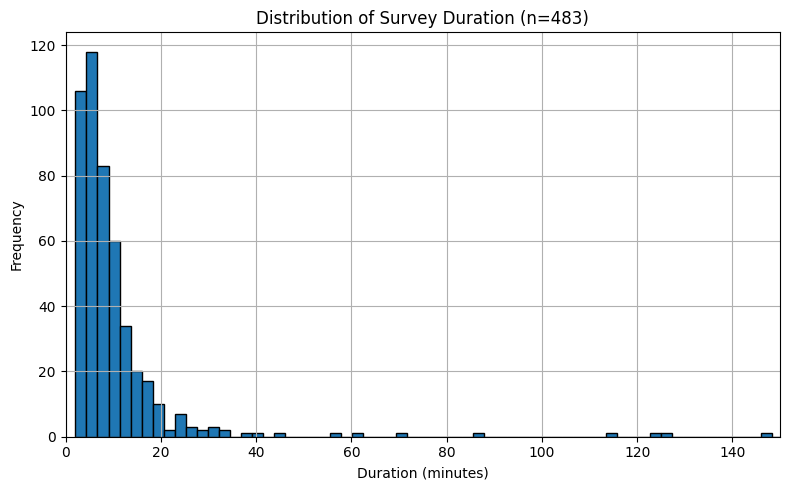

In [30]:
# ============================================================
# Survey completion time
# ============================================================

print(f"Number of eligible responses: {len(df_clean)}")

duration_col = "Durationinseconds"

df_clean[duration_col] = pd.to_numeric(
    df_clean[duration_col],
    errors="coerce",
)

df_clean["duration_min"] = df_clean[duration_col] / 60

print("Survey duration statistics (minutes)")
display(df_clean["duration_min"].describe().round(1))

histogram(
    series=df_clean["duration_min"],
    title=f"Distribution of Survey Duration (n={len(df_clean)})",
    xlabel="Duration (minutes)",
    bins=700,
    xlim=(0, 150),
)

### `6. Current commuting data`

In [42]:
# ============================================================
# Current commuting statistics
# ============================================================
tb_current = ['tb_tt', 'tb_td', 'tb_park', 'TC_e', 'tb_tr', 'tb_tr_late',  'tb_type', 'tb_freq', 'tb_sched']
df_clean[tb_current] = df_clean[tb_current].apply(pd.to_numeric, errors='coerce')

round(df_clean[tb_current].describe(),2)

,tb_tt,tb_td,tb_park,TC_e,tb_tr,tb_tr_late,tb_type,tb_freq,tb_sched
count,483.00,483.00,483.00,483.00,483.00,483.00,483.00,483.00,483.00
mean,27.00,14.78,2.25,3.77,2.69,4.03,0.10,4.04,1.41
std,11.72,10.42,3.57,4.05,1.43,1.69,0.02,1.27,0.65
min,12.50,1.00,0.00,0.09,1.00,1.00,0.07,1.00,1.00
25%,20.00,6.50,0.00,1.13,2.00,3.00,0.09,3.00,1.00
50%,25.00,11.00,0.00,2.28,2.00,4.00,0.12,4.00,1.00
75%,30.00,19.00,3.25,5.05,3.00,5.00,0.12,5.00,2.00
max,90.00,55.00,15.00,21.60,7.00,7.00,0.13,6.00,4.00


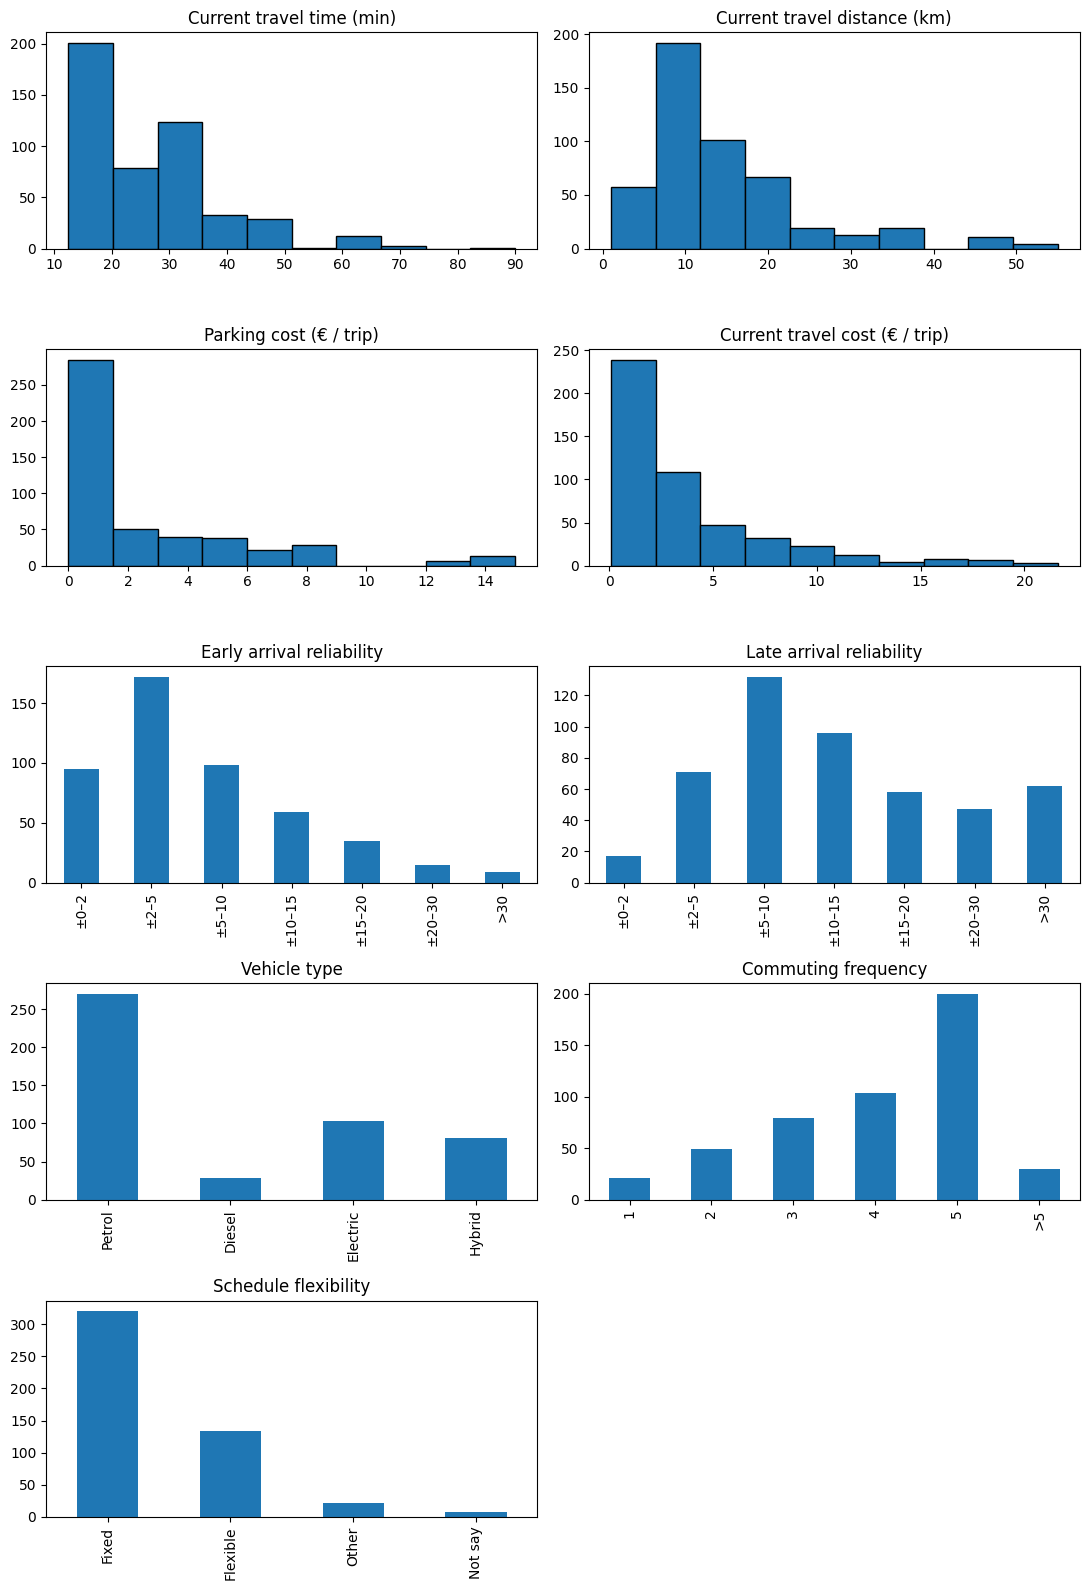

In [43]:
# ============================================================
# Plot current commuting
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(11, 16))
axes = axes.flatten()

for ax, variable in zip(axes, tb_current):
    config = commute_plots[variable]
    if "mapping" in config:
        (
            df_clean[variable]
            .map(config["mapping"])
            .value_counts()
            .reindex(config["order"])
            .plot(kind="bar", ax=ax)
        )
    else:
        df_clean[variable].dropna().hist(
            bins=10,
            edgecolor="black",
            ax=ax,
        )

    ax.set_title(config["title"])
    ax.set_xlabel("")
    ax.grid(False)

# Remove unused subplot
for ax in axes[len(tb_current):]:
    ax.remove()

plt.tight_layout()
plt.show()

### `7. Origin and Destination`

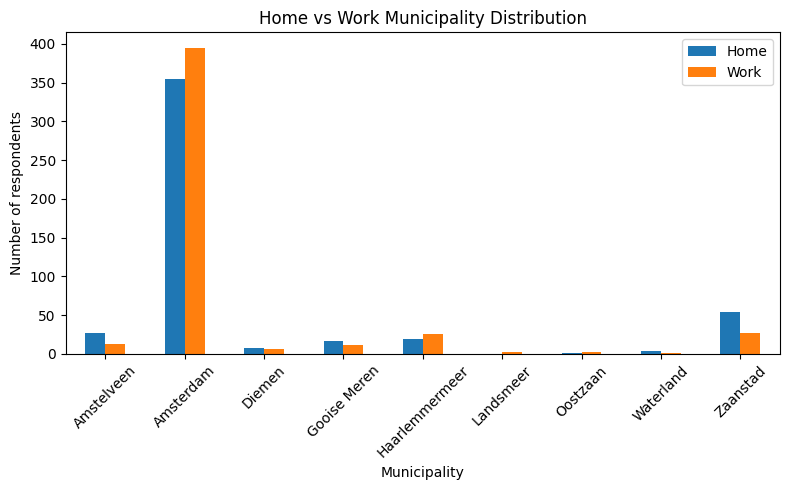

work_municipality  Amstelveen  Amsterdam  Diemen  Gooise Meren  \
home_municipality                                                
Amstelveen                  6         17       0             0   
Amsterdam                   5        327       5             1   
Diemen                      1          5       0             0   
Gooise Meren                0          7       1             9   
Haarlemmermeer              0         10       0             0   
Oostzaan                    0          1       0             0   
Waterland                   0          3       0             0   
Zaanstad                    1         25       0             1   
Total                      13        395       6            11   

work_municipality  Haarlemmermeer  Landsmeer  Oostzaan  Waterland  Zaanstad  \
home_municipality                                                             
Amstelveen                      4          0         0          0         0   
Amsterdam                      10   

In [44]:
# Origin and Destination
# Create distribution table
counts_home = df_clean['home_municipality'].value_counts()
counts_work = df_clean['work_municipality'].value_counts()

df_counts = pd.DataFrame({
    'Home': counts_home,
    'Work': counts_work
}).fillna(0)

# Plot municipality
ax = df_counts.plot(kind='bar')

plt.xlabel("Municipality")
plt.ylabel("Number of respondents")
plt.title("Home vs Work Municipality Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Create OD matrix
od_matrix = pd.crosstab(
    df_clean['home_municipality'],
    df_clean['work_municipality'],
    margins=True,
    margins_name='Total'
)

print(od_matrix)

### `8. Socio-demographic data`

In [45]:
# =============================================================================
# Socio-demographic statistics
# =============================================================================

# age calculation
df_clean['Age_1_TEXT'] = pd.to_numeric(df_clean['Age_1_TEXT'], errors='coerce')

# Keep only realistic birth years
df_clean.loc[
    (df_clean['Age_1_TEXT'] < 1900) |
    (df_clean['Age_1_TEXT'] > 2016),
    'Age_1_TEXT'
] = np.nan

df_clean['age'] = 2026 - df_clean['Age_1_TEXT']

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 20, 40, 65, 80, 120],
    labels=[1, 2, 3, 4, 5],
    right=False
).astype('Int64')

df_clean['age_group'] = df_clean['age_group'].fillna(6)

# socio-demographic data stats
sociodemo = ['age','age_group', 'gender', 'education', 'employment', 'HH_comp', 'HH_income', 'bike', 'PT_subs']
df_clean[sociodemo] = df_clean[sociodemo].apply(pd.to_numeric, errors='coerce')

round(df_clean[sociodemo].describe(),2)

,age,age_group,gender,education,employment,HH_comp,HH_income,bike,PT_subs
count,468.00,483.0,483.00,483.00,483.00,483.00,483.00,483.00,483.00
mean,40.23,2.59,1.39,3.17,1.80,2.62,7.69,2.17,2.86
std,13.50,0.9,0.50,0.84,1.61,0.95,4.12,1.30,1.23
min,19.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,31.00,2.0,1.00,3.00,1.00,2.00,4.00,1.00,2.00
50%,37.00,2.0,1.00,3.00,1.00,3.00,7.00,2.00,3.00
75%,47.00,3.0,2.00,4.00,2.00,3.00,12.00,2.00,4.00
max,89.00,6.0,4.00,6.00,8.00,6.00,16.00,6.00,6.00


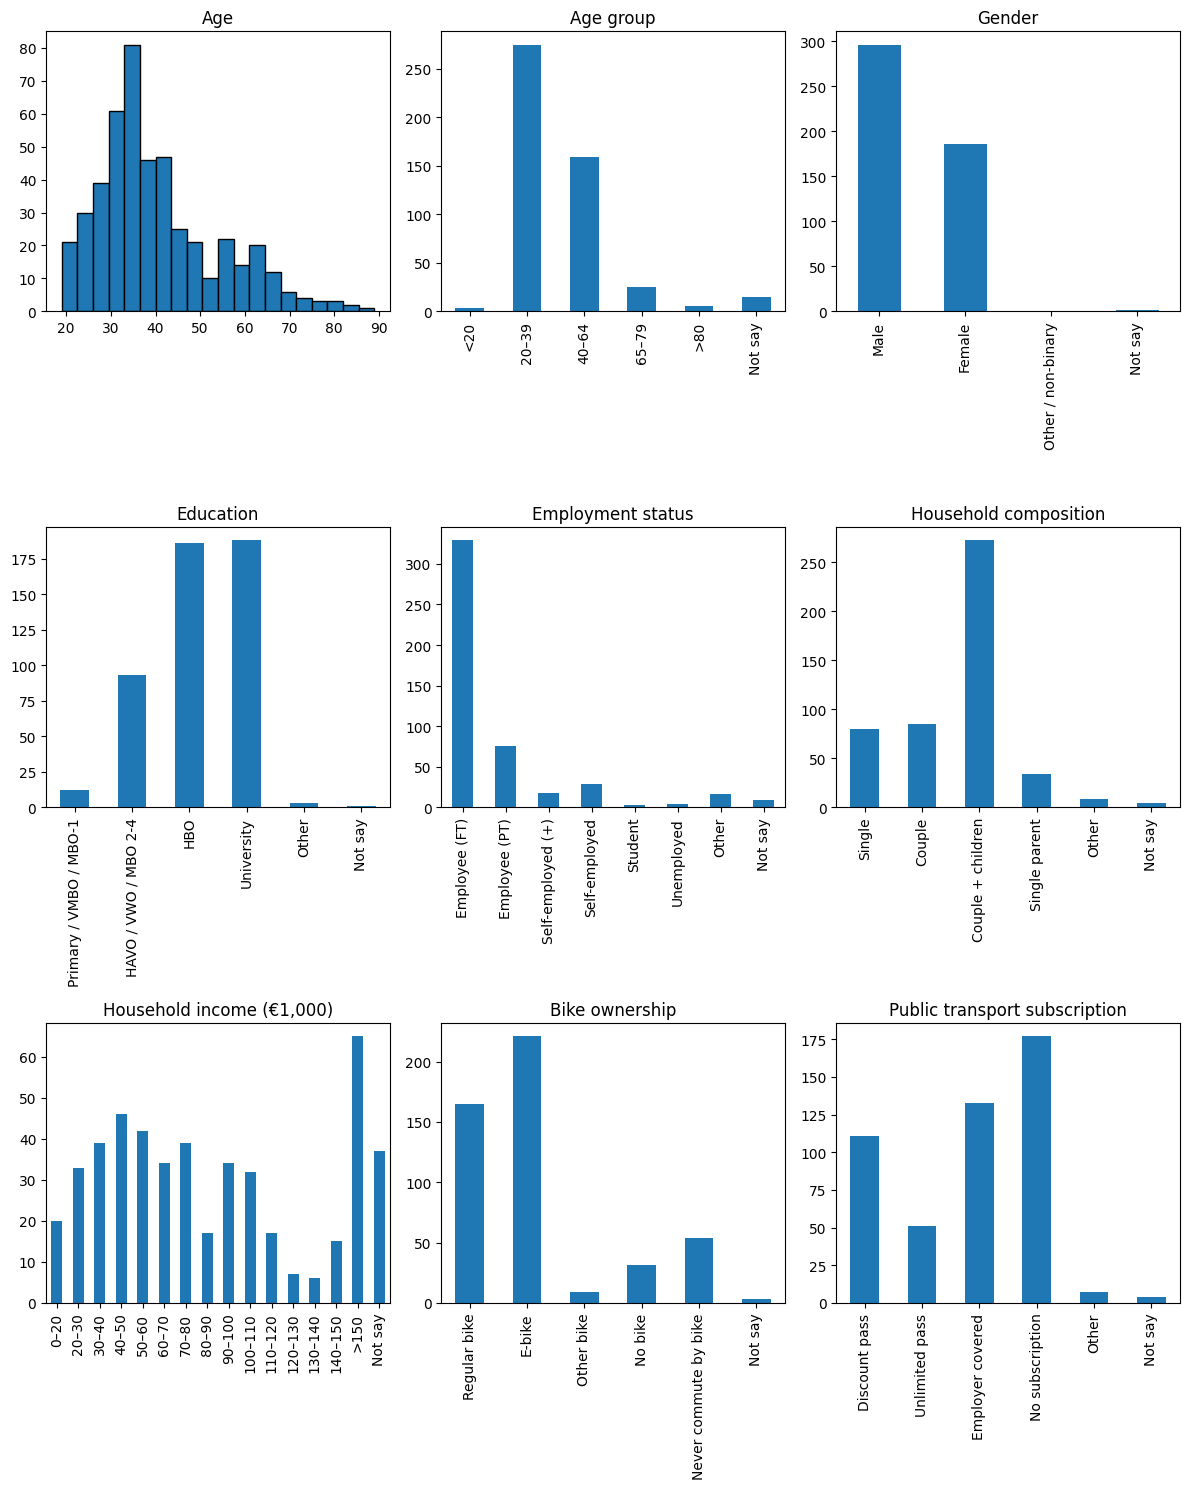

In [46]:
# =============================================================================
# Plot socio-demographic characteristics
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(12, 15))
axes = axes.flatten()

for ax, variable in zip(axes, sociodemo):

    config = SOCIODEMOGRAPHIC_PLOTS[variable]

    if "mapping" in config:

        (
            df_clean[variable]
            .map(config["mapping"])
            .value_counts()
            .reindex(config["order"])
            .plot(kind="bar", ax=ax)
        )

    else:

        df_clean[variable].dropna().hist(
            bins=20,
            edgecolor="black",
            ax=ax,
        )

    ax.set_title(config["title"])
    ax.set_xlabel("")
    ax.grid(False)

for ax in axes[len(sociodemo):]:
    ax.remove()

plt.tight_layout()
plt.show()

### `9. Attitude factors`

In [47]:
# =============================================================================
# Attitude indicators survey
# =============================================================================

# Ensure numeric
df_clean[attitude_cols] = df_clean[attitude_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

# Create count table
attitude_count_table = pd.DataFrame()

for col in attitude_cols:
    counts = (
        df_clean[col]
        .value_counts()
        .reindex([1,2,3,4,5], fill_value=0)
    )

    attitude_count_table[col] = counts

attitude_pct_table = attitude_count_table.div(
    attitude_count_table.sum(axis=1),
    axis=0
) * 100

attitude_pct_table = attitude_pct_table.round(1)

# Transpose for readability
attitude_summary = attitude_count_table.astype(str)

for col in attitude_count_table.columns:
    attitude_summary[col] = (
        attitude_count_table[col].astype(str)
        + ' ('
        + attitude_pct_table[col].astype(str)
        + '%)'
    )

attitude_summary

,Attitude_1_liveability,Attitude_2_equity,Attitude_3_habits,Attitude_4_feasible,Attitude_5_reliability,Attitude_6_variation,Attitude_7_punctual,Attitude_8_uncertainty,Attitude_9_expectation,Attitude_10_adapt,Attitude_11_cycle,Attitude_12_convenience,Attitude_13_confusing,Attitude_14_drive
Attitude_1_liveability,,,,,,,,,,,,,,
1,32 (8.2%),36 (9.3%),41 (10.5%),41 (10.5%),15 (3.9%),33 (8.5%),2 (0.5%),19 (4.9%),24 (6.2%),19 (4.9%),64 (16.5%),47 (12.1%),7 (1.8%),9 (2.3%)
2,68 (7.9%),64 (7.4%),72 (8.3%),68 (7.9%),47 (5.4%),99 (11.4%),24 (2.8%),37 (4.3%),90 (10.4%),86 (9.9%),79 (9.1%),71 (8.2%),33 (3.8%),28 (3.2%)
3,101 (6.7%),122 (8.1%),122 (8.1%),123 (8.2%),105 (7.0%),125 (8.3%),70 (4.6%),109 (7.2%),150 (10.0%),119 (7.9%),88 (5.8%),111 (7.4%),92 (6.1%),70 (4.6%)
4,204 (7.7%),185 (7.0%),182 (6.9%),157 (5.9%),223 (8.4%),171 (6.4%),203 (7.7%),229 (8.6%),152 (5.7%),187 (7.0%),166 (6.3%),180 (6.8%),222 (8.4%),192 (7.2%)
5,78 (5.8%),76 (5.6%),66 (4.9%),94 (7.0%),93 (6.9%),55 (4.1%),184 (13.7%),89 (6.6%),67 (5.0%),72 (5.3%),86 (6.4%),74 (5.5%),129 (9.6%),184 (13.7%)


In [48]:
# =============================================================================
# Extracted attitude factors statistics
# =============================================================================
factors = ['FAC1_support', 'FAC2_uncertainty',	'FAC3_reliability']
df_clean[factors] = df_clean[factors].apply(pd.to_numeric, errors='coerce')

round(df_clean[factors].describe(),2)

,FAC1_support,FAC2_uncertainty,FAC3_reliability
count,483.00,483.00,483.00
mean,-0.00,-0.00,0.00
std,0.95,0.85,0.76
min,-2.65,-1.76,-2.85
25%,-0.62,-0.66,-0.50
50%,0.19,-0.08,0.09
75%,0.73,0.55,0.56
max,1.64,2.39,1.68


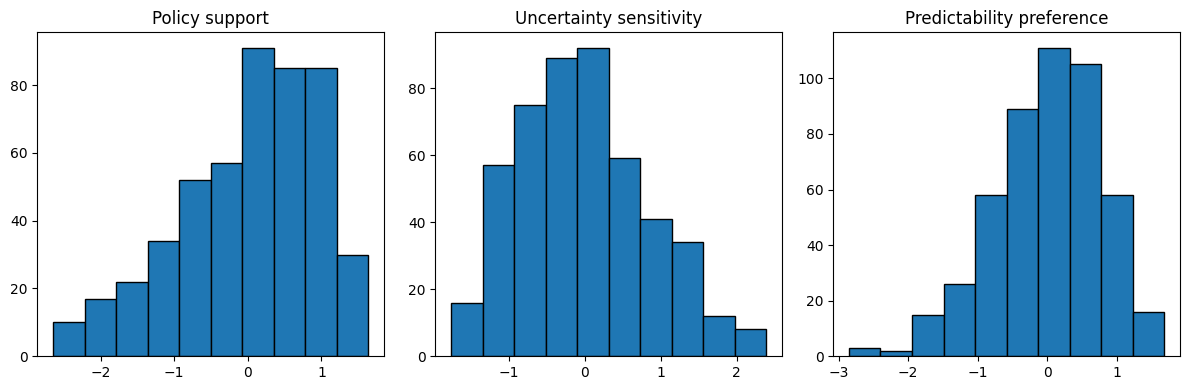

In [49]:
# =============================================================================
# Extracted attitude factors plots
# =============================================================================

titles = {
    'FAC1_support': 'Policy support',
    'FAC2_uncertainty': 'Uncertainty sensitivity',
    'FAC3_reliability': 'Predictability preference'
}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(factors):
    df_clean[col].dropna().hist(ax=axes[i], edgecolor='black')

    axes[i].set_title(titles[col])
    axes[i].set_xlabel(None)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### `10. Choice frequency`

In [53]:
# Counts the number of times each  alternative is chosen
choice_freq = df_long_recode['CHOICE'].value_counts()

# Calculate the percentage of the chosen alternatives
choice_percent = round(choice_freq / len(df_long_recode['CHOICE']) * 100,2)

# Table Summary
choice_table = pd.DataFrame({'Choice': choice_freq.index, 'Frequency': choice_freq.values, 'Percentage':choice_percent.values} )

# Show the table
choice_table

,Choice,Frequency,Percentage
0,1,2474,56.91
1,2,1224,28.16
2,3,649,14.93


### `11. Data pre-processing for MNL estimation`

In [51]:
# =============================================================================
# Prepare choice in long table format
# =============================================================================
# Load data
df = df_clean.copy()

# Prepare design table
design.columns = design.columns.str.strip().str.lower()

# Recognise choice profile and block in df (example column: "@3_SP_answer_block_1)"
choice_cols = [col for col in df.columns if '_SP_answer_' in col]
pattern = r'@(\d+)_SP_answer_block_(\d+)'

# Prepare long table
long_rows = []

for idx, row in df.iterrows():
    respondent_id = row['ResponseId']

    for col in choice_cols:
        match = re.match(pattern, col)
        if not match:
            continue
        
        profile = int(match.group(1))
        block = int(match.group(2))
        choice = row[col]

        # Skip missing responses
        if pd.isna(choice) or str(choice).strip() == '':
            continue

        # Lookup design attributes
        design_row = design[
            (design['profile'] == profile) &
            (design['block'] == block)
        ]

        if design_row.empty:
            continue

        design_row = design_row.iloc[0]

        # Build row
        new_row = {
            'ID': respondent_id,
            'profile': profile,
            'block': block,

            # Choice
            'CHOICE': choice,

            # Availability (assume all available)
            'AV1': 1,
            'AV2': 1,
            'AV3': 1
        }

        # Add design attributes
        for col_name in design.columns:
            if col_name not in ['profile', 'block']:
                new_row[col_name] = design_row[col_name]

        # Add socio-demographics
        sociodemo_cols = [
            'tb_tt','tb_tr','tb_tr_late','tb_td','tb_type','tb_park','TC_e','tb_freq',
            'home_municipality','work_municipality','tb_sched',
            'age','age_group','gender','education','employment','HH_comp','HH_income','bike','PT_subs',
            'FAC1_support', 'FAC2_uncertainty', 'FAC3_reliability'
        ]

        for sd in sociodemo_cols:
            new_row[sd] = row.get(sd, None)

        long_rows.append(new_row)

# Convert to DataFrame
df_long_recode = pd.DataFrame(long_rows)


# =============================================================================
# Variable recoding
# =============================================================================

# Combine others and rather not say options
# Add reference category for each variable

#age group (combine other and rather not say)
agegroup_map = {1:0, 2:1, 3:2, 4:2, 5:4, 6:5}
df_long_recode['age_group'] = df_long_recode['age_group'].map(agegroup_map)

#gender (combine other and rather not say)
gender_map = {1:0, 2:1, 3:1, 4:1}
df_long_recode['gender'] = df_long_recode['gender'].map(gender_map)

#education (combine other and rather not say to primary education)
edu_map = {1:0, 2:1, 3:2, 4:3, 5:0, 6:0}
df_long_recode['education'] = df_long_recode['education'].map(edu_map)

# employment (combine student, unemployed, other, and rather not say into one category, and self-employed combined)
employ_map = {1:0, 2:1, 3:2, 4:2, 5:3, 6:3, 7:3, 8:3}
df_long_recode['employment'] = df_long_recode['employment'].map(employ_map)

# HH composition (combine other and rather not say)
HH_map = {1:0, 2:1, 3:2, 4:3, 5:4, 6:4}
df_long_recode['HH_comp'] = df_long_recode['HH_comp'].map(HH_map)

# Map household income group
income_map = {
    1:0, 2:0, 3:0, 4:0,
    5:1, 6:1, 7:1, 8:1, 9:1,
    10:2, 11:2, 14:2, 15:2, 16:2,
    12:3,
    13:4
    }
df_long_recode['income_group'] = (df_long_recode['HH_income'].map(income_map))

# Bike (combine other bike to regular bike and combine no bike, never bike, and not say)
bike_map = {1:1, 2:2, 3:1, 4:0, 5:0, 6:0}
df_long_recode['bike'] = df_long_recode['bike'].map(bike_map)

# PT subs (combine other and not say)
subs_map = {1:1, 2:2, 3:3, 4:0, 5:3, 6:3}
df_long_recode['PT_subs'] = df_long_recode['PT_subs'].map(subs_map)

# tb_sched
schedule_map = {1:0, 2:1, 3:2, 4:2}
df_long_recode['tb_sched'] = df_long_recode['tb_sched'].map(schedule_map)

# tb_freq
freq_map = {1:1, 2:2, 3:3, 4:4, 5:5, 6:0}
df_long_recode['tb_freq'] = df_long_recode['tb_freq'].map(freq_map)

# Encode municipalities numerically
municipality_map = {
    'Amsterdam': 1,
    'Amstelveen': 0,
    'Diemen': 0,
    'Gooise Meren': 0,
    'Haarlemmermeer': 0,
    'Landsmeer': 0,
    'Oostzaan': 0,
    'Waterland': 0,
    'Zaanstad': 0
}

df_long_recode['home_municipality'] = (
    df_long_recode['home_municipality']
    .map(municipality_map)
)

df_long_recode['work_municipality'] = (
    df_long_recode['work_municipality']
    .map(municipality_map)
)

# =============================================================================
# Prepare long table
# =============================================================================

# Create numeric panel ID (1,2,3,...)
df_long_recode['ID_new'] = pd.factorize(df_long_recode['ID'])[0] + 1
df_long_recode['ID'] = df_long_recode['ID_new']
df_long_recode = df_long_recode.drop(columns=['ID_new'])

df_long_recode['age'] = df_long_recode['age'].fillna(0).astype(int)
df_long_recode['age_group'] = df_long_recode['age_group'].fillna(1).astype(int)

df_long_recode['income_group'] = df_long_recode['income_group'].fillna(4).astype(int)

# Column order
final_cols = [
    'ID','profile','block',
    'time_car','rbt_car','cost_car',
    'time_bus','rbt_bus','crowd_bus','cost_bus',
    'time_bike','rbt_bike',
    'tb_tt','tb_tr','tb_tr_late','tb_td','tb_type','tb_park','TC_e','tb_freq','home_municipality','work_municipality','tb_sched',
    'age','age_group','gender','education','employment','HH_comp','HH_income','income_group','bike','PT_subs',
    'FAC1_support', 'FAC2_uncertainty', 'FAC3_reliability',
    'CHOICE','AV1','AV2','AV3'
]

df_long_recode = df_long_recode[final_cols]

# Enforce numeric to the data
for col in df_long_recode.columns:
    try:
        df_long_recode[col] = pd.to_numeric(df_long_recode[col])
    except:
        pass

# Check profiles per respondent
print(df_long_recode.groupby(['ID','block']).size().value_counts())

# Print output
df_long_recode.to_csv('sp_long_format_recode.csv', index=False)

# Preview table
df_long_recode.head()

9    483
Name: count, dtype: int64


,ID,profile,block,time_car,rbt_car,cost_car,time_bus,rbt_bus,crowd_bus,cost_bus,time_bike,rbt_bike,tb_tt,tb_tr,tb_tr_late,tb_td,tb_type,tb_park,TC_e,tb_freq,home_municipality,work_municipality,tb_sched,age,age_group,gender,education,employment,HH_comp,HH_income,income_group,bike,PT_subs,FAC1_support,FAC2_uncertainty,FAC3_reliability,CHOICE,AV1,AV2,AV3
0,1,1,2,30,10,0,10,10,2,2,15,3,30.0,3,4,3.5,0.12,0.5,0.92,4,1,1,0,0,5,1,3,0,2,4,0,1,3,-0.512959,0.223114,-0.71888,2,1,1,1
1,1,2,2,10,10,4,0,3,3,4,15,5,30.0,3,4,3.5,0.12,0.5,0.92,4,1,1,0,0,5,1,3,0,2,4,0,1,3,-0.512959,0.223114,-0.71888,1,1,1,1
2,1,3,2,20,10,2,-10,5,1,0,15,10,30.0,3,4,3.5,0.12,0.5,0.92,4,1,1,0,0,5,1,3,0,2,4,0,1,3,-0.512959,0.223114,-0.71888,2,1,1,1
3,1,4,2,30,5,4,-10,3,3,2,25,3,30.0,3,4,3.5,0.12,0.5,0.92,4,1,1,0,0,5,1,3,0,2,4,0,1,3,-0.512959,0.223114,-0.71888,2,1,1,1
4,1,5,2,10,5,2,10,5,1,4,25,5,30.0,3,4,3.5,0.12,0.5,0.92,4,1,1,0,0,5,1,3,0,2,4,0,1,3,-0.512959,0.223114,-0.71888,1,1,1,1
